# Keyword Filtering

In [117]:
import json
import copy
import os
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

## Config

In [119]:
# keywords to keep per cluster in the final output
TOP_N = 5

# blend weights based on tfidf cluster-specific words score and identity relevance
TFIDF_WEIGHT     = 0.5
RELEVANCE_WEIGHT = 0.5

## Load summaries

In [120]:
with open("../../data/clusters/artist_cluster_summary.json") as f:
    artist_summary = json.load(f)

with open("../../data/clusters/institution_cluster_summary.json") as f:
    institution_summary = json.load(f)

print(f"artist n values:      {[e['n'] for e in artist_summary['numClusters']]}")
print(f"institution n values: {[e['n'] for e in institution_summary['numClusters']]}")

artist n values:      [7, 8, 10, 9, 11, 12, 13, 15]
institution n values: [7, 8, 9, 10, 11, 12, 13, 15]


## Scoring + flagging duplicates

In [127]:
def combined_score(kw, tfidf_w=TFIDF_WEIGHT, relevance_w=RELEVANCE_WEIGHT):
    return tfidf_w * kw['tfidf_score'] + relevance_w * kw['relevance_score']


def process_groups(groups, top_n=TOP_N):
    groups = copy.deepcopy(groups)

    # re-rank by combined score
    kw_lists = []
    for g in groups:
        ranked = sorted(g['keywords'], key=combined_score, reverse=True)
        for kw in ranked:
            kw['combined_score'] = round(combined_score(kw), 4)
        kw_lists.append(ranked)

    # build map of word → sorted list of cluster ids that contain it
    word_clusters = defaultdict(set)
    for g, kws in zip(groups, kw_lists):
        for kw in kws:
            word_clusters[kw['word']].add(g['id'])
    duplicated_words = {w: sorted(ids) for w, ids in word_clusters.items() if len(ids) > 1}

    for kws in kw_lists:
        for kw in kws:
            kw.pop('is_duplicated', None)
            cluster_ids = duplicated_words.get(kw['word'])
            if cluster_ids is not None:
                kw['duplicated'] = cluster_ids

    # resolve top-word conflicts: move loser's top word to bottom
    changed = True
    while changed:
        changed = False
        seen = {}
        for i, kws in enumerate(kw_lists):
            if not kws:
                continue
            top_word = kws[0]['word']
            if top_word in seen:
                j = seen[top_word]
                winner = j if kw_lists[i][0]['tfidf_score'] <= kw_lists[j][0]['tfidf_score'] else i
                loser  = i if winner == j else j
                seen[top_word] = winner
                loser_kws = kw_lists[loser]
                kw_lists[loser] = loser_kws[1:] + [loser_kws[0]]
                changed = True
                break
            else:
                seen[top_word] = i

    for g, kws in zip(groups, kw_lists):
        g['keywords'] = kws[:top_n]

    return groups

## Process artist summary

In [128]:
artist_out = copy.deepcopy(artist_summary)

for entry in artist_out['numClusters']:
    entry['groups'] = process_groups(entry['groups'])

for entry in artist_out['numClusters']:
    print(f"\n=== n={entry['n']} ===")
    for g in entry['groups']:
        kw_strs = [f"{k['word']} (c={k['combined_score']:.2f} tfidf={k['tfidf_score']:.2f} rel={k['relevance_score']:.2f})" for k in g['keywords']]
        print(f"  cluster {g['id']}: {', '.join(kw_strs)}")


=== n=7 ===
  cluster 1: oriental (c=0.77 tfidf=1.00 rel=0.55), masterprint (c=0.55 tfidf=0.60 rel=0.51), masterprints (c=0.55 tfidf=0.60 rel=0.50), flowers (c=0.47 tfidf=0.40 rel=0.54), flower (c=0.43 tfidf=0.33 rel=0.52)
  cluster 3: untitled (c=0.77 tfidf=1.00 rel=0.55), portfolio (c=0.38 tfidf=0.22 rel=0.54), flowers (c=0.36 tfidf=0.18 rel=0.54), nude (c=0.31 tfidf=0.11 rel=0.52), abstraction (c=0.31 tfidf=0.07 rel=0.55)
  cluster 5: like (c=0.78 tfidf=1.00 rel=0.56), people (c=0.71 tfidf=0.85 rel=0.58), social (c=0.61 tfidf=0.67 rel=0.56), constantly (c=0.59 tfidf=0.65 rel=0.54), digital (c=0.58 tfidf=0.62 rel=0.55)
  cluster 0: asian (c=0.78 tfidf=1.00 rel=0.56), american (c=0.48 tfidf=0.41 rel=0.55), chinese (c=0.48 tfidf=0.39 rel=0.57), anonymous (c=0.47 tfidf=0.37 rel=0.56), people (c=0.45 tfidf=0.32 rel=0.58)
  cluster 6: filipino (c=0.77 tfidf=1.00 rel=0.55), american (c=0.74 tfidf=0.94 rel=0.55), country (c=0.71 tfidf=0.85 rel=0.56), family (c=0.67 tfidf=0.77 rel=0.58), co

## Process institution summary

In [129]:
institution_out = copy.deepcopy(institution_summary)

for entry in institution_out['numClusters']:
    entry['groups'] = process_groups(entry['groups'])

# preview
for entry in institution_out['numClusters']:
    print(f"\n=== n={entry['n']} ===")
    for g in entry['groups']:
        kw_strs = [f"{k['word']} (c={k['combined_score']:.2f} tfidf={k['tfidf_score']:.2f} rel={k['relevance_score']:.2f})" for k in g['keywords']]
        print(f"  cluster {g['id']}: {', '.join(kw_strs)}")


=== n=7 ===
  cluster 2: female (c=0.75 tfidf=1.00 rel=0.49), male (c=0.66 tfidf=0.83 rel=0.49), asian (c=0.39 tfidf=0.21 rel=0.56), american (c=0.35 tfidf=0.15 rel=0.55), flanked (c=0.28 tfidf=0.00 rel=0.55)
  cluster 6: born (c=0.76 tfidf=1.00 rel=0.52), american (c=0.64 tfidf=0.74 rel=0.55), philippines (c=0.33 tfidf=0.15 rel=0.51), china (c=0.30 tfidf=0.05 rel=0.55), died (c=0.30 tfidf=0.13 rel=0.46)
  cluster 4: japanese (c=0.64 tfidf=0.73 rel=0.56), ancestry (c=0.57 tfidf=0.57 rel=0.57), family (c=0.55 tfidf=0.52 rel=0.58), known (c=0.52 tfidf=0.52 rel=0.51), korean (c=0.51 tfidf=0.48 rel=0.54)
  cluster 1: contemporary (c=0.61 tfidf=0.61 rel=0.60), painter (c=0.58 tfidf=0.61 rel=0.56), university (c=0.56 tfidf=0.61 rel=0.51), installation (c=0.56 tfidf=0.61 rel=0.51), california (c=0.56 tfidf=0.62 rel=0.50)
  cluster 3: american (c=0.78 tfidf=1.00 rel=0.55), japanese (c=0.75 tfidf=0.95 rel=0.56), people (c=0.74 tfidf=0.90 rel=0.58), culture (c=0.74 tfidf=0.90 rel=0.58), history

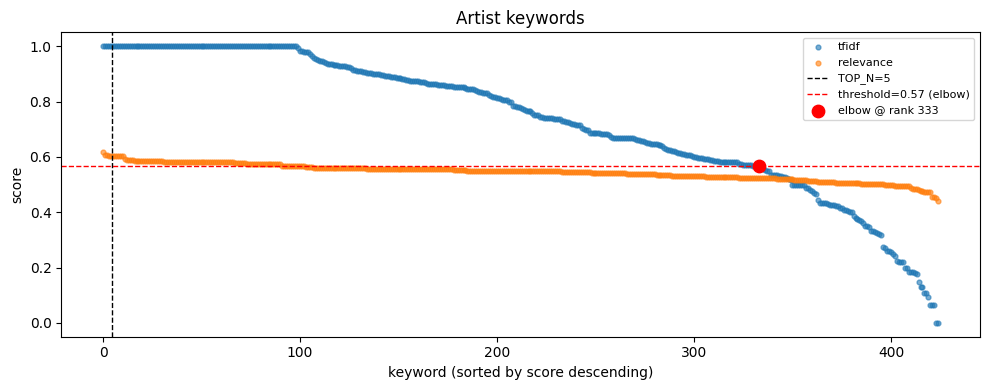

  elbow: rank 333, tfidf=0.566 — 334 keywords above threshold


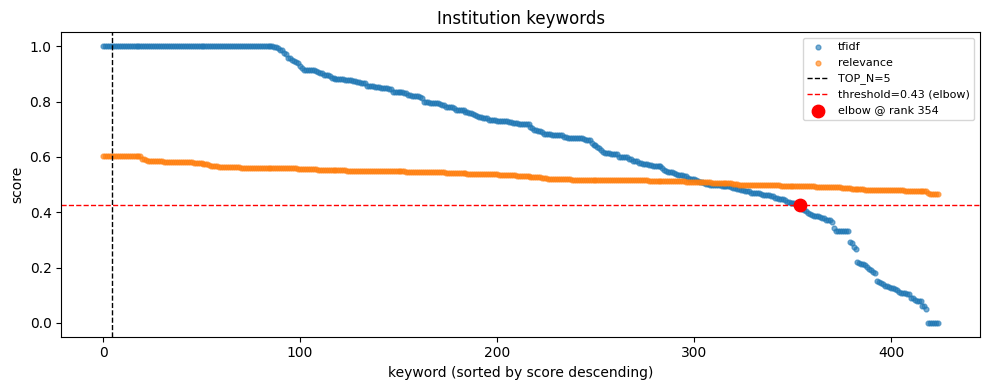

  elbow: rank 354, tfidf=0.428 — 355 keywords above threshold


In [124]:
ARTIST_TFIDF_THRESHOLD      = None 
INSTITUTION_TFIDF_THRESHOLD = None

def collect_scores(summary_out):
    tfidf, relevance = [], []
    for entry in summary_out['numClusters']:
        for g in entry['groups']:
            for kw in g['keywords']:
                tfidf.append(kw['tfidf_score'])
                relevance.append(kw['relevance_score'])
    return sorted(tfidf, reverse=True), sorted(relevance, reverse=True)


def find_elbow(scores):
    n = len(scores)
    if n < 3:
        return 0, scores[0]
    arr = np.array(scores)
    lo, hi = arr.min(), arr.max()
    y = (arr - lo) / (hi - lo) if hi > lo else arr
    x = np.linspace(0, 1, n)
    distances = np.abs(x + y - 1) / np.sqrt(2)
    idx = int(np.argmax(distances))
    return idx, scores[idx]


def plot_scores(summary_out, title, top_n=TOP_N, threshold=None):
    tfidf_sorted, relevance_sorted = collect_scores(summary_out)
    elbow_idx, elbow_val = find_elbow(tfidf_sorted)
    thresh = threshold if threshold is not None else elbow_val

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(range(len(tfidf_sorted)),     tfidf_sorted,     s=12, alpha=0.6, label='tfidf')
    ax.scatter(range(len(relevance_sorted)), relevance_sorted, s=12, alpha=0.6, label='relevance')
    ax.axvline(top_n - 0.5,  color='black', linestyle='--', linewidth=1, label=f'TOP_N={top_n}')
    ax.axhline(thresh, color='red', linestyle='--', linewidth=1, label=f'threshold={thresh:.2f} ({"manual" if threshold is not None else "elbow"})')
    ax.scatter(elbow_idx, elbow_val, s=80, color='red', zorder=6, label=f'elbow @ rank {elbow_idx}')
    ax.set_xlabel('keyword (sorted by score descending)')
    ax.set_ylabel('score')
    ax.set_title(title)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    print(f'  elbow: rank {elbow_idx}, tfidf={elbow_val:.3f} — {sum(s >= thresh for s in tfidf_sorted)} keywords above threshold')


plot_scores(artist_out,      'Artist keywords',      threshold=ARTIST_TFIDF_THRESHOLD)
plot_scores(institution_out, 'Institution keywords', threshold=INSTITUTION_TFIDF_THRESHOLD)

### Threshold filtering

Find threshold from above where score curve transitions between steep drop --> longer flat. This transition is when small differences between TF-IDF scores don't mean as much, keywords are more bunched together - below this threshold TF-IDF score stops being as useful a signal to describe how well a word fits a cluster

In [131]:
# filter close to elbow with some padding since duplicates are included still
ARTIST_TFIDF_THRESHOLD      = 0.5

# lower for inst since more generic is expected and we need no empty keywords
INSTITUTION_TFIDF_THRESHOLD = 0.15

for entry in artist_out['numClusters']:
    for g in entry['groups']:
        g['keywords'] = [kw for kw in g['keywords'] if kw['tfidf_score'] >= ARTIST_TFIDF_THRESHOLD]

for entry in institution_out['numClusters']:
    for g in entry['groups']:
        g['keywords'] = [kw for kw in g['keywords'] if kw['tfidf_score'] >= INSTITUTION_TFIDF_THRESHOLD]

## Write output

In [ ]:
def text_only(summary_out):
    return [
        {
            "n": entry["n"],
            "clusters": [
                {
                    "id": g["id"],
                    "featured_quote": g.get("featured_quote", ""),
                    "keywords": g["keywords"]
                }
                for g in sorted(entry["groups"], key=lambda g: g["id"])
            ]
        }
        for entry in summary_out["numClusters"]
    ]


with open("./manual_artist_cluster.json", "w") as f:
    json.dump(text_only(artist_out), f, indent=2, ensure_ascii=False)

with open("./manual_inst_cluster.json", "w") as f:
    json.dump(text_only(institution_out), f, indent=2, ensure_ascii=False)

print("Wrote manual review files")

Wrote manual review files


## Apply verified keywords → overwrite cluster summaries

Edit `manual_artist_cluster.json` and `manual_inst_cluster.json` first,
then run this cell to reload them and overwrite the originals with plain keyword arrays.

In [133]:
with open("./manual_artist_cluster.json") as f:
    artist_manual = json.load(f)

with open("./manual_inst_cluster.json") as f:
    institution_manual = json.load(f)


def apply_keywords(full_summary, slim_manual):
    out = copy.deepcopy(full_summary)
    index = {
        entry["n"]: {str(c["id"]): c["keywords"] for c in entry["clusters"]}
        for entry in slim_manual
    }
    for entry in out["numClusters"]:
        cluster_map = index.get(entry["n"], {})
        for g in entry["groups"]:
            if str(g["id"]) in cluster_map:
                g["keywords"] = [kw["word"] for kw in cluster_map[str(g["id"])]]
    return out


with open("../../data/clusters/artist_cluster_summary.json", "w") as f:
    json.dump(apply_keywords(artist_summary, artist_manual), f, indent=2, ensure_ascii=False)

with open("../../data/clusters/institution_cluster_summary.json", "w") as f:
    json.dump(apply_keywords(institution_summary, institution_manual), f, indent=2, ensure_ascii=False)


os.remove("./manual_artist_cluster.json")
os.remove("./manual_inst_cluster.json")

print("Cluster summaries overwritten with verified keywords")

Cluster summaries overwritten with verified keywords
